In [66]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from PNW_cmap import PNW_cmap
import matplotlib.pyplot as plt
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.plotting.plot_session_heatmap import plot_glutamate_session,plot_mean_image_response_heatmaps


from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [4]:
%matplotlib notebook

In [5]:
%load_ext autoreload
%autoreload 2

In [6]:
today_str = datetime.today().strftime('%Y-%m-%d')

In [7]:
save_path = r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Data_Club\April2026\figures"

In [8]:
target_mice = [
    803496,
    804730,804733,810196,
    809047,803121,
    826033,838410,834788
]

In [9]:
registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check","volume_imaging"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

In [10]:
IM_COLORS = [
    '#c5cae9', '#ffcdd2', '#c8e6c9', '#ffe0b2',
    '#e1bee7', '#d7ccc8', '#9fd3f2'
]

In [37]:
asset = assets[21]
print(asset.session_id)

810196_2025-07-31_08-28-08


<IPython.core.display.Javascript object>


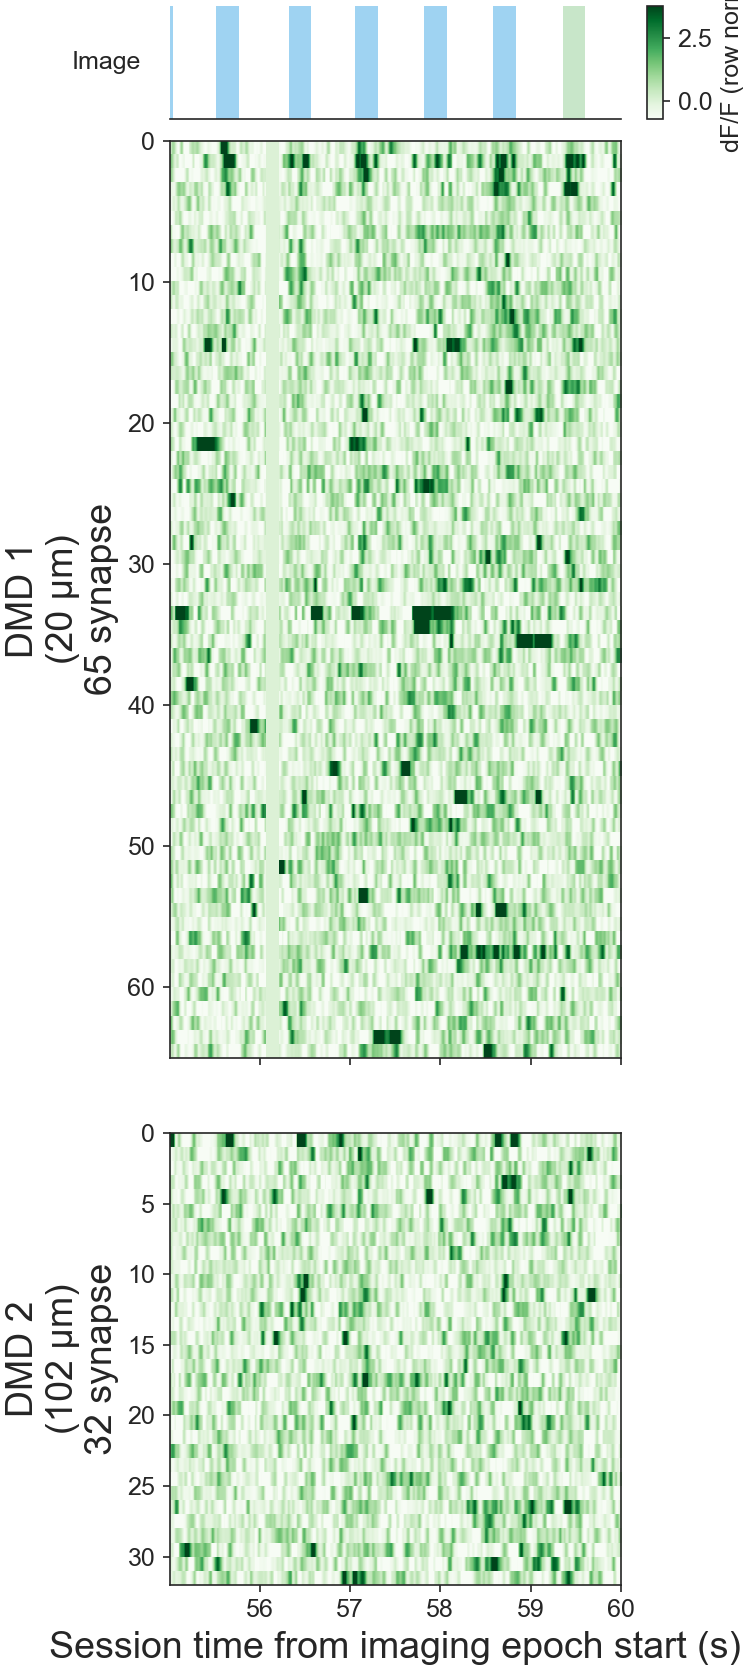

In [57]:
out = plot_glutamate_session(
    asset=asset,
    signal="dF",
    mode="ls",
    channels="glutamate",
    xlim_sec=(55, 60),
    normalize_rows="zscore",
    display_smooth_sigma=3,
    feature_smooth_sigma=2.0,
    sort_by="pc1_raw",  # try also: "rastermap_raw", "stimulus_locked_per_image"
    show_image_bar=True,
    show_sort_trace=False,
    sort_trace_source_dmd=1,
    show_running_trace=False,
    encoder_units="degrees",  # change to "cm" if your encoder column is already cumulative cm
    speed_units="cm/s",
    running_median_filter_kernel=200,
    wheel_radius_cm=8.225,
    image_flash_duration=0.25,
    cmap_session="Greens",
    session_percentiles=(10, 99),
    figsize_width=5,
    synapse_height=0.10,
    min_whole_height=0.5,
    image_bar_height=0.8,
    running_trace_height=0.9,
    sort_trace_height=0.9,
    show_row_labels=True,
    image_bar_ylabel="Image",
    running_ylabel="Speed\n(cm/s)",
    sort_trace_ylabel="PC1",
    session_xlabel="Session time from imaging epoch start (s)",
    session_ylabel_template="DMD {dmd}\n({depth_txt})\n{n_syn} synapse",
    cbar_label="dF/F (row norm)",
    label_kwargs={"fontsize": 12},
    image_bar_ylabel_kwargs={"fontsize": 12},
    running_ylabel_kwargs={"fontsize": 12},
    sort_trace_ylabel_kwargs={"fontsize": 12},
    session_xlabel_kwargs={"fontsize": 18},
    session_ylabel_kwargs={"fontsize": 18},
    cbar_label_kwargs={"fontsize": 12},
    x_tick_params={"labelsize": 12, "top": False},
    y_tick_params={"labelsize": 12, "right": False},
)

fig = out["fig"]
fig.patch.set_alpha(0)
filen = f'{today_str}_{asset.session_id}_heatmap_55-60'
# save_figure(fig,os.path.join(save_path,filen),formats=['.pdf'],dpi=300)

In [61]:
behavior_qc_path = glob.glob(os.path.join(asset.qc_dir,'behavior','behavior_validation.json'))[0]

with open(behavior_qc_path, "r") as f:
    b_qc = json.load(f)
    
im_names = b_qc['bonsai_validation']['stimulus_names']

In [62]:
im_names

['stimuli\\images_B\\100075.tiff',
 'stimuli\\images_B\\216066.tiff',
 'stimuli\\images_B\\268048.tiff',
 'stimuli\\images_B\\69022.tiff',
 'stimuli\\images_B\\McGill_stairs.tiff',
 'stimuli\\images_B\\imk01306.tiff',
 'stimuli\\images_B\\imk01333.tiff']

<IPython.core.display.Javascript object>


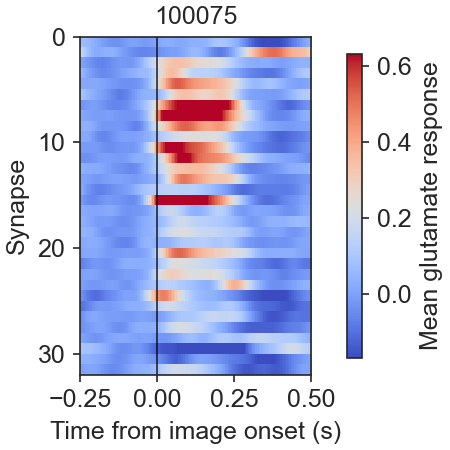

In [83]:
out = plot_mean_image_response_heatmaps(
    asset=asset,
    dmd=2,
    image_name=im_names[0],
    as_grid=False,
    signal="dF",
    mode="ls",
    channels="glutamate",
    normalize_rows="zscore",
    baseline_subtract=True,
    baseline_window=(-0.25, 0.0),
    smooth_sigma=5,
    sort_by="pc1_per_image",
    cmap="coolwarm",
    percentiles=(2, 98),
    figsize=(3, 3),
    xlabel="Time from image onset (s)",
    ylabel="Synapse",
    cbar_label="Mean glutamate response",
    label_kwargs={"fontsize": 12},
    title_kwargs={"fontsize": 12},
    cbar_label_kwargs={"fontsize": 12},
    x_tick_params=dict(axis="x", which="major", reset=True, top=False, labelsize=12),
    y_tick_params=dict(axis="y", which="major", reset=True, right=False, labelsize=12),
)

fig,ax=out['fig'],out['ax']
ax.set_xlim(-0.25,0.5)
plt.show()
fig.patch.set_alpha(0)
filen = f'{today_str}_{asset.session_id}_im1_dmd2'
save_figure(fig,os.path.join(save_path,filen),formats=['.pdf'],dpi=300)